# KUIS 2 - Sistem Pendukung Keputusan
**Nama  : Aidatul Rosida**  
**Kelas : SIB-3C**

In [69]:
# 1. IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [70]:
# 2. UPLOAD FILE (WAJIB DI COLAB)

from google.colab import files
uploaded = files.upload()

Saving Data_Klaim.csv to Data_Klaim (2).csv
Saving Data_Polis.csv to Data_Polis (2).csv


In [71]:
# 3. LOAD DATA

klaim = pd.read_csv('Data_Klaim.csv')
polis = pd.read_csv('Data_Polis.csv')

print("Shape Klaim :", klaim.shape)
print("Shape Polis :", polis.shape)
print("\n--- Preview Klaim ---")
display(klaim.head(3))
print("\n--- Preview Polis ---")
display(polis.head(3))

Shape Klaim : (4627, 13)
Shape Polis : (4096, 6)

--- Preview Klaim ---


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore



--- Preview Polis ---


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA


In [72]:
# 4. PREPROCESSING

# === MERGE ===
df = klaim.merge(polis, on='Nomor Polis', how='left')

# === HITUNG DURASI RAWAT ===
df['Tanggal Pasien Masuk RS']  = pd.to_datetime(df['Tanggal Pasien Masuk RS'],  errors='coerce')
df['Tanggal Pasien Keluar RS'] = pd.to_datetime(df['Tanggal Pasien Keluar RS'], errors='coerce')
df['Durasi'] = (df['Tanggal Pasien Keluar RS'] - df['Tanggal Pasien Masuk RS']).dt.days.fillna(0)

# === AMBIL KOLOM KRITERIA ===
raw = df[['Claim ID',
          'Nominal Klaim Yang Disetujui',
          'Nominal Biaya RS Yang Terjadi',
          'Durasi']].dropna().reset_index(drop=True)

raw.columns = ['Alternatif', 'C1', 'C2', 'C3']
raw['Alternatif'] = ['A' + str(i+1) for i in range(len(raw))]
raw = raw[['Alternatif', 'C1', 'C2', 'C3']]

print(f"Total data tersedia: {len(raw)} baris")
display(raw.head(10))

Total data tersedia: 4627 baris


,Alternatif,C1,C2,C3
0,A1,2.809365e+07,6.143948e+06,0
1,A2,8.098728e+07,8.230952e+07,0
2,A3,1.830471e+08,1.928599e+08,0
3,A4,1.914244e+08,1.914244e+08,0
4,A5,1.389364e+08,1.389364e+08,0
5,A6,1.360160e+08,1.368552e+08,0
6,A7,1.341925e+08,1.347333e+08,0
7,A8,5.398718e+08,3.164563e+08,0
8,A9,1.340855e+08,1.340855e+08,0
9,A10,3.229387e+07,0.000000e+00,0


In [73]:
# === BOBOT DAN TIPE KRITERIA (SAMA untuk SAW, EDAS, TOPSIS) ===
# C1: Nominal Klaim Disetujui  -> BENEFIT (makin besar makin baik)
# C2: Biaya RS                 -> COST    (makin kecil makin baik)
# C3: Durasi Rawat             -> BENEFIT (makin lama = lebih berat ditanggung = makin relevan)

weights    = np.array([0.4, 0.4, 0.2])   # bobot tiap kriteria
criteria   = ['C1', 'C2', 'C3']
crit_type  = {'C1': 'benefit', 'C2': 'cost', 'C3': 'benefit'}

print("Bobot Kriteria:")
for i, c in enumerate(criteria):
    print(f"  {c} [{crit_type[c].upper():7s}] = {weights[i]}")
print(f"\nTotal bobot: {weights.sum():.1f} ✓")

Bobot Kriteria:
  C1 [BENEFIT] = 0.4
  C2 [COST   ] = 0.4
  C3 [BENEFIT] = 0.2

Total bobot: 1.0 ✓


In [76]:
# 6. METODE SAW

# --- Normalisasi SAW ---
norm_saw = pd.DataFrame(index=raw.index)
for col in criteria:
    if crit_type[col] == 'benefit':
        norm_saw[col] = raw[col] / raw[col].max()
    else:  # cost
        norm_saw[col] = raw[col].min() / raw[col]

# --- Hitung Skor SAW ---
raw['SAW_Score'] = norm_saw.values.dot(weights)

# --- Ranking SAW ---
ranking_saw = raw[['Alternatif', 'SAW_Score']].sort_values('SAW_Score', ascending=False).reset_index(drop=True)
ranking_saw.insert(0, 'Urutan', range(1, len(ranking_saw) + 1))

print("=== TABEL RANKING SAW (Top 10) ===")
display(ranking_saw.head(10))

=== TABEL RANKING SAW (Top 10) ===


,Urutan,Alternatif,SAW_Score
0,1,A905,0.456860
1,2,A325,0.429630
2,3,A253,0.389277
3,4,A368,0.382469
4,5,A965,0.345636
5,6,A2105,0.317651
6,7,A1505,0.301728
7,8,A1484,0.297700
8,9,A4017,0.278288
9,10,A380,0.274232


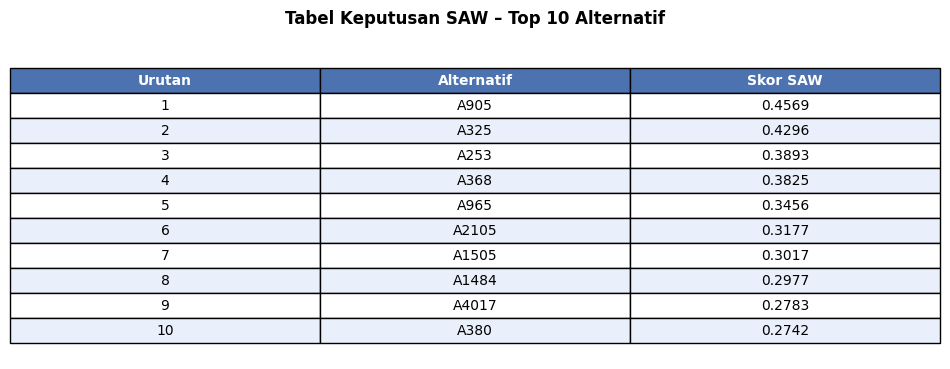

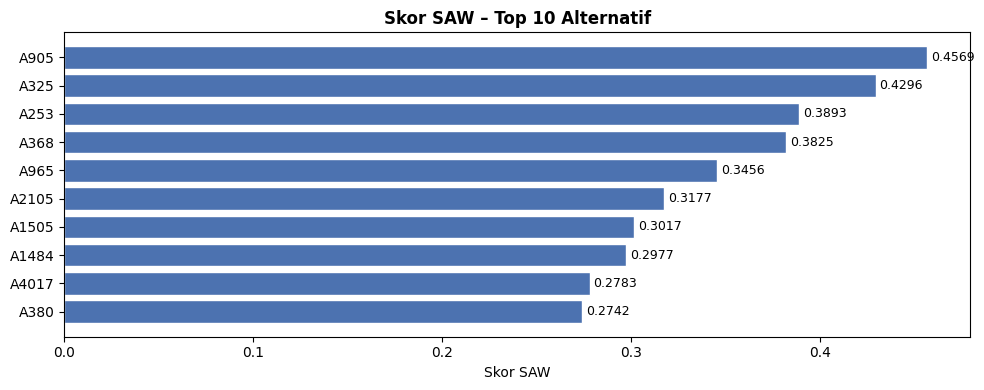

In [77]:
# Visualisasi Tabel Keputusan SAW

top10_saw = ranking_saw.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data = [top10_saw.columns.tolist()] + top10_saw.values.tolist()
table_data[0] = ['Urutan', 'Alternatif', 'Skor SAW']
for row in table_data[1:]:
    row[2] = f"{row[2]:.4f}"

tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#EAF0FB')

plt.title('Tabel Keputusan SAW – Top 10 Alternatif', fontweight='bold', pad=20)
plt.savefig('tabel_saw.png', bbox_inches='tight', dpi=150)
plt.show()

# Bar chart skor SAW
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(top10_saw['Alternatif'][::-1], top10_saw['SAW_Score'][::-1],
               color='#4C72B0', edgecolor='white')
ax.set_xlabel('Skor SAW')
ax.set_title('Skor SAW – Top 10 Alternatif', fontweight='bold')
for bar, val in zip(bars, top10_saw['SAW_Score'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_saw.png', bbox_inches='tight', dpi=150)
plt.show()

In [78]:
# METODE EDAS

# --- Rata-rata tiap kriteria ---
avg = raw[criteria].mean()

pda = pd.DataFrame(index=raw.index)
nda = pd.DataFrame(index=raw.index)

for col in criteria:
    if crit_type[col] == 'benefit':
        pda[col] = np.maximum(0, (raw[col] - avg[col]) / avg[col])
        nda[col] = np.maximum(0, (avg[col] - raw[col]) / avg[col])
    else:  # cost
        pda[col] = np.maximum(0, (avg[col] - raw[col]) / avg[col])
        nda[col] = np.maximum(0, (raw[col] - avg[col]) / avg[col])

# --- SP & SN ---
sp = pda.values.dot(weights)
sn = nda.values.dot(weights)

# --- Normalisasi SP & SN ---
nsp = sp / sp.max() if sp.max() != 0 else sp
nsn = 1 - (sn / sn.max()) if sn.max() != 0 else np.ones(len(sn))

# --- Skor EDAS ---
raw['EDAS_Score'] = (nsp + nsn) / 2

# --- Ranking EDAS ---
ranking_edas = raw[['Alternatif', 'EDAS_Score']].sort_values('EDAS_Score', ascending=False).reset_index(drop=True)
ranking_edas.insert(0, 'Urutan', range(1, len(ranking_edas) + 1))

print("=== TABEL RANKING EDAS (Top 10) ===")
display(ranking_edas.head(10))

=== TABEL RANKING EDAS (Top 10) ===


,Urutan,Alternatif,EDAS_Score
0,1,A905,0.816628
1,2,A4017,0.727677
2,3,A3993,0.657545
3,4,A3541,0.654022
4,5,A368,0.647695
5,6,A253,0.642137
6,7,A3746,0.640586
7,8,A251,0.637557
8,9,A2666,0.627866
9,10,A1874,0.624332


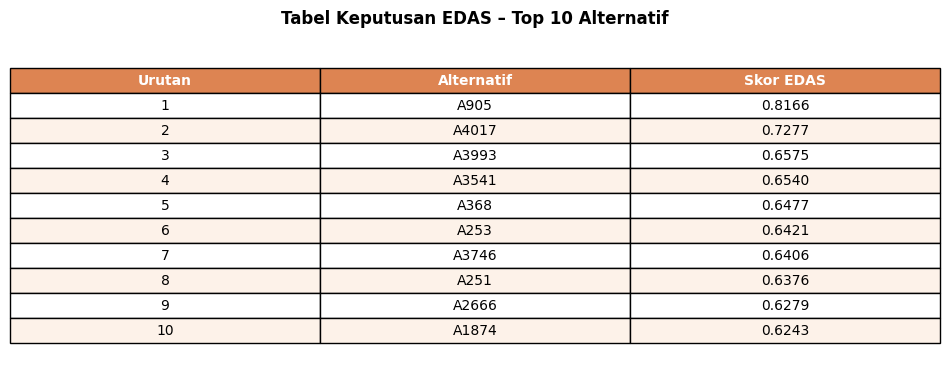

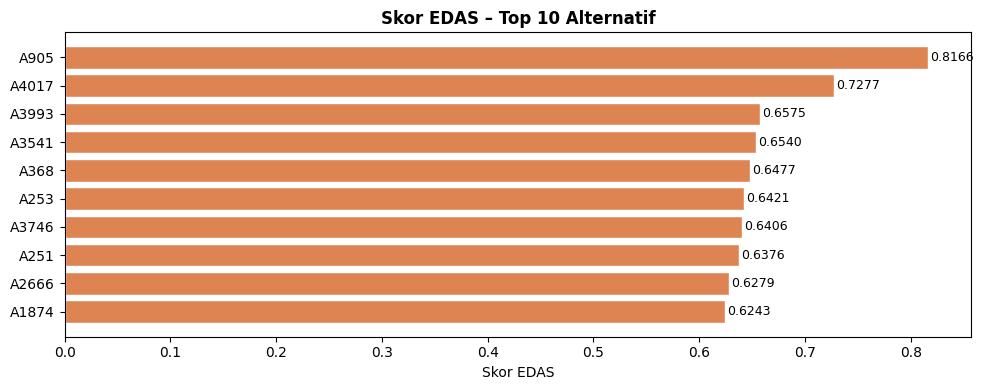

In [79]:
# Visualisasi Tabel Keputusan EDAS

top10_edas = ranking_edas.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data_e = [['Urutan', 'Alternatif', 'Skor EDAS']]
for _, row in top10_edas.iterrows():
    table_data_e.append([int(row['Urutan']), row['Alternatif'], f"{row['EDAS_Score']:.4f}"])

tbl_e = ax.table(cellText=table_data_e[1:], colLabels=table_data_e[0],
                 loc='center', cellLoc='center')
tbl_e.auto_set_font_size(False)
tbl_e.set_fontsize(10)
tbl_e.scale(1.2, 1.5)

for (row, col), cell in tbl_e.get_celld().items():
    if row == 0:
        cell.set_facecolor('#DD8452')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#FDF2E9')

plt.title('Tabel Keputusan EDAS – Top 10 Alternatif', fontweight='bold', pad=20)
plt.savefig('tabel_edas.png', bbox_inches='tight', dpi=150)
plt.show()

# Bar chart EDAS
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top10_edas['Alternatif'][::-1], top10_edas['EDAS_Score'][::-1],
        color='#DD8452', edgecolor='white')
ax.set_xlabel('Skor EDAS')
ax.set_title('Skor EDAS – Top 10 Alternatif', fontweight='bold')
for bar, val in zip(ax.patches, top10_edas['EDAS_Score'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_edas.png', bbox_inches='tight', dpi=150)
plt.show()

In [80]:
# 8. METODE TOPSIS

# --- Normalisasi Euclidean TOPSIS ---
norm_topsis = pd.DataFrame(index=raw.index)
for col in criteria:
    denom = np.sqrt((raw[col] ** 2).sum())
    norm_topsis[col] = raw[col] / denom if denom != 0 else 0

# --- Matriks Terbobot ---
weighted_topsis = norm_topsis * weights

# --- Solusi Ideal Positif & Negatif ---
ideal_pos = pd.Series(dtype=float)
ideal_neg = pd.Series(dtype=float)

for col in criteria:
    if crit_type[col] == 'benefit':
        ideal_pos[col] = weighted_topsis[col].max()
        ideal_neg[col] = weighted_topsis[col].min()
    else:  # cost
        ideal_pos[col] = weighted_topsis[col].min()
        ideal_neg[col] = weighted_topsis[col].max()

# --- Jarak D+ dan D- ---
dist_pos = np.sqrt(((weighted_topsis - ideal_pos) ** 2).sum(axis=1))
dist_neg = np.sqrt(((weighted_topsis - ideal_neg) ** 2).sum(axis=1))

# --- Skor TOPSIS ---
raw['TOPSIS_Score'] = dist_neg / (dist_pos + dist_neg)

# --- Ranking TOPSIS ---
ranking_topsis = raw[['Alternatif', 'TOPSIS_Score']].sort_values('TOPSIS_Score', ascending=False).reset_index(drop=True)
ranking_topsis.insert(0, 'Urutan', range(1, len(ranking_topsis) + 1))

print("=== TABEL RANKING TOPSIS (Top 10) ===")
display(ranking_topsis.head(10))


=== TABEL RANKING TOPSIS (Top 10) ===


,Urutan,Alternatif,TOPSIS_Score
0,1,A905,0.653899
1,2,A4017,0.630465
2,3,A3993,0.621073
3,4,A3541,0.617939
4,5,A2666,0.611303
5,6,A251,0.609395
6,7,A589,0.608396
7,8,A3746,0.608033
8,9,A3240,0.603475
9,10,A3503,0.603340


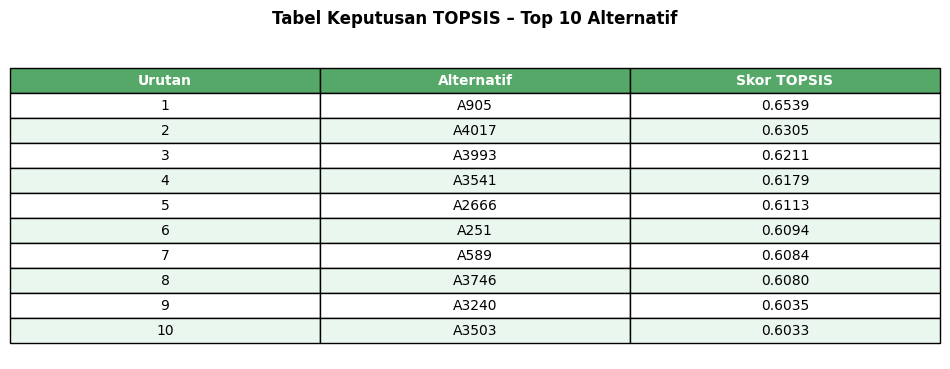

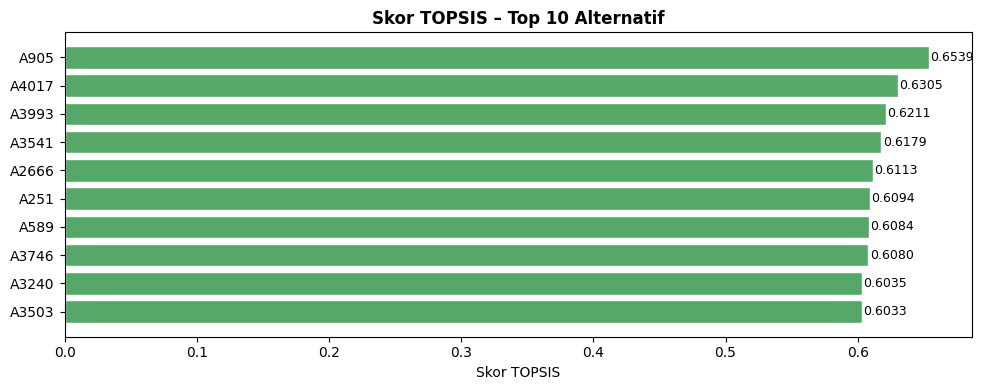

In [81]:
# Visualisasi Tabel Keputusan TOPSIS

top10_topsis = ranking_topsis.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data_t = [['Urutan', 'Alternatif', 'Skor TOPSIS']]
for _, row in top10_topsis.iterrows():
    table_data_t.append([int(row['Urutan']), row['Alternatif'], f"{row['TOPSIS_Score']:.4f}"])

tbl_t = ax.table(cellText=table_data_t[1:], colLabels=table_data_t[0],
                 loc='center', cellLoc='center')
tbl_t.auto_set_font_size(False)
tbl_t.set_fontsize(10)
tbl_t.scale(1.2, 1.5)

for (row, col), cell in tbl_t.get_celld().items():
    if row == 0:
        cell.set_facecolor('#55A868')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#EAF7EE')

plt.title('Tabel Keputusan TOPSIS – Top 10 Alternatif', fontweight='bold', pad=20)
plt.savefig('tabel_topsis.png', bbox_inches='tight', dpi=150)
plt.show()

# Bar chart TOPSIS
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top10_topsis['Alternatif'][::-1], top10_topsis['TOPSIS_Score'][::-1],
        color='#55A868', edgecolor='white')
ax.set_xlabel('Skor TOPSIS')
ax.set_title('Skor TOPSIS – Top 10 Alternatif', fontweight='bold')
for bar, val in zip(ax.patches, top10_topsis['TOPSIS_Score'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_topsis.png', bbox_inches='tight', dpi=150)
plt.show()

In [82]:
# 9. TABEL PERBANDINGAN

# --- Susun tabel perbandingan Top 10 ---
top_n = 10

perbandingan = pd.DataFrame({
    'Urutan' : range(1, top_n + 1),
    'SAW'    : ranking_saw.head(top_n)['Alternatif'].values,
    'EDAS'   : ranking_edas.head(top_n)['Alternatif'].values,
    'TOPSIS' : ranking_topsis.head(top_n)['Alternatif'].values,
})

# --- Tandai kemiripan SAW vs EDAS ---
perbandingan['SAW=EDAS']    = perbandingan['SAW'] == perbandingan['EDAS']
perbandingan['SAW=TOPSIS']  = perbandingan['SAW'] == perbandingan['TOPSIS']
perbandingan['EDAS=TOPSIS'] = perbandingan['EDAS'] == perbandingan['TOPSIS']
perbandingan['SEMUA_SAMA']  = perbandingan['SAW=EDAS'] & perbandingan['SAW=TOPSIS']

print("=== TABEL PERBANDINGAN SAW vs EDAS vs TOPSIS (Top 10) ===")
display(perbandingan)

=== TABEL PERBANDINGAN SAW vs EDAS vs TOPSIS (Top 10) ===


,Urutan,SAW,EDAS,TOPSIS,SAW=EDAS,SAW=TOPSIS,EDAS=TOPSIS,SEMUA_SAMA
0,1,A905,A905,A905,True,True,True,True
1,2,A325,A4017,A4017,False,False,True,False
2,3,A253,A3993,A3993,False,False,True,False
3,4,A368,A3541,A3541,False,False,True,False
4,5,A965,A368,A2666,False,False,False,False
5,6,A2105,A253,A251,False,False,False,False
6,7,A1505,A3746,A589,False,False,False,False
7,8,A1484,A251,A3746,False,False,False,False
8,9,A4017,A2666,A3240,False,False,False,False
9,10,A380,A1874,A3503,False,False,False,False


In [84]:
# 11. ANALISIS KEMIRIPAN

# --- Analisis kemiripan SAW vs EDAS ---
same_se   = perbandingan['SAW=EDAS'].sum()
diff_se   = top_n - same_se
pct_same_se = (same_se / top_n) * 100
pct_diff_se = 100 - pct_same_se

# --- Analisis kemiripan SAW vs TOPSIS ---
same_st   = perbandingan['SAW=TOPSIS'].sum()
diff_st   = top_n - same_st
pct_same_st = (same_st / top_n) * 100

# --- Analisis kemiripan EDAS vs TOPSIS ---
same_et   = perbandingan['EDAS=TOPSIS'].sum()
diff_et   = top_n - same_et
pct_same_et = (same_et / top_n) * 100

# --- Semua sama ---
same_all  = perbandingan['SEMUA_SAMA'].sum()

print("=== ANALISIS KEMIRIPAN (Top 10) ===")
print(f"\n[SAW vs EDAS]")
print(f"  Jumlah posisi SAMA  : {same_se} dari {top_n}")
print(f"  Jumlah posisi BEDA  : {diff_se} dari {top_n}")
print(f"  Persentase sama     : {pct_same_se:.1f}%")
print(f"  Persentase berbeda  : {pct_diff_se:.1f}%")

if diff_se > 0:
    beda_rows = perbandingan[~perbandingan['SAW=EDAS']]
    print(f"  Posisi berbeda (SAW vs EDAS):")
    for _, r in beda_rows.iterrows():
        print(f"    Urutan {int(r['Urutan'])}: SAW={r['SAW']}, EDAS={r['EDAS']}")

print(f"\n[SAW vs TOPSIS]")
print(f"  Jumlah posisi SAMA  : {same_st} dari {top_n} ({(same_st/top_n)*100:.1f}%)")
print(f"  Jumlah posisi BEDA  : {diff_st} dari {top_n}")

print(f"\n[EDAS vs TOPSIS]")
print(f"  Jumlah posisi SAMA  : {same_et} dari {top_n} ({(same_et/top_n)*100:.1f}%)")
print(f"  Jumlah posisi BEDA  : {diff_et} dari {top_n}")

print(f"\n[Ketiganya SAMA di posisi yang sama]: {same_all} dari {top_n}")

=== ANALISIS KEMIRIPAN (Top 10) ===

[SAW vs EDAS]
  Jumlah posisi SAMA  : 1 dari 10
  Jumlah posisi BEDA  : 9 dari 10
  Persentase sama     : 10.0%
  Persentase berbeda  : 90.0%
  Posisi berbeda (SAW vs EDAS):
    Urutan 2: SAW=A325, EDAS=A4017
    Urutan 3: SAW=A253, EDAS=A3993
    Urutan 4: SAW=A368, EDAS=A3541
    Urutan 5: SAW=A965, EDAS=A368
    Urutan 6: SAW=A2105, EDAS=A253
    Urutan 7: SAW=A1505, EDAS=A3746
    Urutan 8: SAW=A1484, EDAS=A251
    Urutan 9: SAW=A4017, EDAS=A2666
    Urutan 10: SAW=A380, EDAS=A1874

[SAW vs TOPSIS]
  Jumlah posisi SAMA  : 1 dari 10 (10.0%)
  Jumlah posisi BEDA  : 9 dari 10

[EDAS vs TOPSIS]
  Jumlah posisi SAMA  : 4 dari 10 (40.0%)
  Jumlah posisi BEDA  : 6 dari 10

[Ketiganya SAMA di posisi yang sama]: 1 dari 10


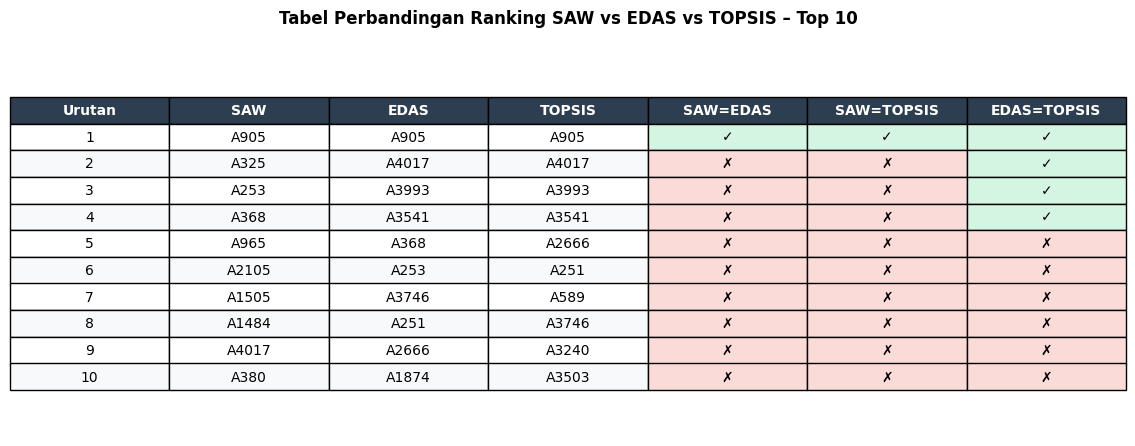

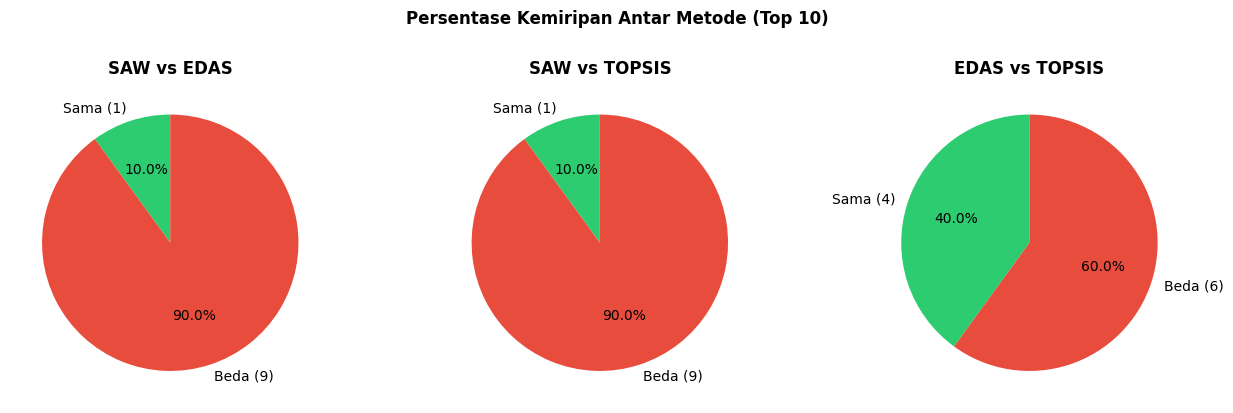

In [85]:
# Visualisasi Perbandingan

# --- Tabel perbandingan visual ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

col_labels = ['Urutan', 'SAW', 'EDAS', 'TOPSIS', 'SAW=EDAS', 'SAW=TOPSIS', 'EDAS=TOPSIS']
cell_data = []
for _, row in perbandingan.iterrows():
    cell_data.append([
        int(row['Urutan']), row['SAW'], row['EDAS'], row['TOPSIS'],
        '✓' if row['SAW=EDAS'] else '✗',
        '✓' if row['SAW=TOPSIS'] else '✗',
        '✓' if row['EDAS=TOPSIS'] else '✗'
    ])

tbl_p = ax.table(cellText=cell_data, colLabels=col_labels, loc='center', cellLoc='center')
tbl_p.auto_set_font_size(False)
tbl_p.set_fontsize(10)
tbl_p.scale(1.2, 1.6)

for (row, col), cell in tbl_p.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F8F9FA')
    # Warnai hasil kemiripan
    if row > 0 and col in [4, 5, 6]:
        txt = cell_data[row-1][col]
        cell.set_facecolor('#D5F5E3' if txt == '✓' else '#FADBD8')

plt.title('Tabel Perbandingan Ranking SAW vs EDAS vs TOPSIS – Top 10', fontweight='bold', pad=20)
plt.savefig('tabel_perbandingan.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Pie chart kemiripan SAW vs EDAS ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [
    ('SAW vs EDAS',    same_se,  diff_se),
    ('SAW vs TOPSIS',  same_st,  diff_st),
    ('EDAS vs TOPSIS', same_et,  diff_et),
]
for ax, (title, same, diff) in zip(axes, pairs):
    if same + diff == 0:
        continue
    ax.pie([same, diff],
           labels=[f'Sama ({same})', f'Beda ({diff})'],
           colors=['#2ECC71', '#E74C3C'],
           autopct='%1.1f%%', startangle=90,
           textprops={'fontsize': 10})
    ax.set_title(title, fontweight='bold')

plt.suptitle('Persentase Kemiripan Antar Metode (Top 10)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pie_kemiripan.png', bbox_inches='tight', dpi=150)
plt.show()

In [87]:
# 11. SAVE CSV (FINAL)

# --- Gabungkan semua ranking ke satu dataframe final ---
final_df = raw[['Alternatif', 'C1', 'C2', 'C3', 'SAW_Score', 'EDAS_Score', 'TOPSIS_Score']].copy()

# Isi NaN dulu sebelum rank
final_df['SAW_Score']    = final_df['SAW_Score'].fillna(0)
final_df['EDAS_Score']   = final_df['EDAS_Score'].fillna(0)
final_df['TOPSIS_Score'] = final_df['TOPSIS_Score'].fillna(0)

final_df['Rank_SAW']    = final_df['SAW_Score'].rank(ascending=False, method='min').astype(int)
final_df['Rank_EDAS']   = final_df['EDAS_Score'].rank(ascending=False, method='min').astype(int)
final_df['Rank_TOPSIS'] = final_df['TOPSIS_Score'].rank(ascending=False, method='min').astype(int)

# Urutkan berdasarkan ranking SAW
final_df = final_df.sort_values('Rank_SAW').reset_index(drop=True)

# Simpan CSV
final_df.to_csv('hasil_perbandingan_final.csv', index=False)
print("File 'hasil_perbandingan_final.csv' berhasil disimpan.")
print(f"Total baris: {len(final_df)}")

display(final_df.head(10))

# Download
files.download('hasil_perbandingan_final.csv')

File 'hasil_perbandingan_final.csv' berhasil disimpan.
Total baris: 4627


,Alternatif,C1,C2,C3,SAW_Score,EDAS_Score,TOPSIS_Score,Rank_SAW,Rank_EDAS,Rank_TOPSIS
0,A905,1.411122e+09,1.465628e+09,54,0.456860,0.816628,0.653899,1,1,1
1,A325,2.197500e+09,3.192700e+09,8,0.429630,0.548426,0.443203,2,101,4625
2,A253,1.813035e+09,2.152368e+09,16,0.389277,0.642137,0.536878,3,6,4619
3,A368,1.938410e+09,2.035137e+09,8,0.382469,0.647695,0.553705,4,5,4615
4,A965,1.756406e+09,1.905637e+09,7,0.345636,0.623898,0.552716,5,11,4617
5,A2105,1.643362e+09,1.912347e+09,5,0.317651,0.591757,0.536546,6,29,4620
6,A1505,1.352412e+09,2.364316e+09,15,0.301728,0.518162,0.448847,7,459,4624
7,A1484,1.411669e+09,1.835873e+09,11,0.297700,0.581546,0.531252,8,41,4622
8,A4017,5.318305e+08,6.349548e+08,49,0.278288,0.727677,0.630465,9,2,2
9,A380,1.404824e+09,1.438373e+09,5,0.274232,0.605955,0.579019,10,17,129


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## SUMMARY — Ringkasan Hasil & Analisis

### 1. Pemrosesan Dataset
- Dataset gabungan dari **Data_Klaim.csv** dan **Data_Polis.csv** (merge by `Nomor Polis`)
- Dibuat fitur baru: **Durasi** = selisih hari keluar – masuk RS
- Tiga kriteria digunakan:
  | Kriteria | Deskripsi | Tipe | Bobot |
  |----------|-----------|------|-------|
  | C1 | Nominal Klaim Disetujui | Benefit | 0.4 |
  | C2 | Biaya RS | Cost | 0.4 |
  | C3 | Durasi Rawat | Benefit | 0.2 |
- **Bobot dan tipe kriteria IDENTIK** untuk ketiga metode

### 2. Proses SAW
- Normalisasi: Benefit = nilai/max, Cost = min/nilai
- Skor = dot product (nilai ternormalisasi × bobot)
- Alternatif terbaik = skor SAW tertinggi

### 3. Proses EDAS
- Hitung jarak positif (PDA) dan negatif (NDA) dari rata-rata
- Benefit: PDA = max(0, x−AV)/AV; Cost: PDA = max(0, AV−x)/AV
- Normalisasi SP dan SN → Skor AS = (NSP + NSN) / 2

### 4. Proses TOPSIS
- Normalisasi Euclidean per kriteria
- Matriks terbobot → tentukan A+ dan A−
- Skor CC = D− / (D+ + D−); semakin tinggi semakin dekat ke ideal positif

### 5. Analisis Perbandingan
- Perbandingan dilakukan pada **Top 10 alternatif** dari masing-masing metode
- Kemiripan dihitung per posisi urutan
- Hasil lengkap tersimpan di **hasil_perbandingan_final.csv**

### 6. Kesimpulan
- SAW merupakan metode paling sederhana; cocok untuk dataset yang terstruktur dan bobot sudah jelas
- EDAS mempertimbangkan deviasi terhadap rata-rata; lebih robust terhadap outlier
- TOPSIS menggunakan jarak geometri ke solusi ideal; cocok ketika batas ideal atas-bawah perlu dipertimbangkan
- Semakin tinggi persentase kemiripan antar metode → semakin **konsisten** keputusan yang dihasilkan